# Rail Operations Forecaster
## Notebook 08 — Decision Support Layer

**Business Objective:**  
Translate predicted next-day terminal dwell hours into actionable decision-support signals for rail operations leaders. This notebook builds a transparent, rules-based classification layer on top of the tuned LightGBM forecasts from Phase 1.

> **Audience:** This notebook is written for operations analysts, terminal managers, and technical reviewers who want to see how a forecasting model connects to day-to-day operational decisions.

## Why decision support comes after forecasting

The Rail Operations Forecaster project does not directly predict operating ratio (OR). Instead, it forecasts operational drivers that are upstream of OR — specifically, next-day terminal dwell hours — and then uses those forecasts to support operational decisions.

A raw predicted dwell value, such as 25.3 hours, is not immediately actionable on its own. Operations leaders need a clear signal: is this a normal day, an elevated-risk day, or a day that warrants intervention? This notebook builds that signal by applying simple, transparent business rules to the model output.

This approach has several practical advantages:

- **Transparency:** The classification rules are explicit and easy to explain to non-technical stakeholders.
- **Adjustability:** Thresholds can be reviewed and updated by operations leaders without retraining the model.
- **Accountability:** Decisions remain with human operators; the model provides structured guidance, not autonomous commands.

The decision-support signals here are derived from the tuned Phase 1 LightGBM model — the strongest forecasting benchmark available after Phase 2 temporal modeling experiments failed to clear the performance gate.

The 24-hour dwell threshold used here is consistent with the scenario analysis introduced in Notebook 06.

In [1]:
from pathlib import Path

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

np.random.seed(42)

print("Imports OK")
print("LightGBM version:", lgb.__version__)

Imports OK
LightGBM version: 4.6.0


## Load and prepare the dataset

The same Phase 1 terminal dwell dataset is used here. The dataset covers 8 terminals from approximately 2022-01-01 through 2024-12-31 and contains 8,760 rows.

Terminal identity is passed directly to LightGBM as a native categorical feature. No dummy encoding is applied, consistent with the Phase 1 tuned model setup.

In [5]:
project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "synthetic" / "phase1_terminal_dwell.csv"

df = pd.read_csv(data_path, parse_dates=["date"])
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)
df["terminal_id"] = df["terminal_id"].astype("category")

target_col = "target_dwell_hours"
split_date = pd.Timestamp("2024-07-01")

base_feature_cols = [
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

# terminal_id is used directly as a categorical feature — no dummy encoding
model_feature_cols = base_feature_cols + ["terminal_id"]

df_model = df[
    ["date", "terminal_id", "terminal_name", "region", target_col] + base_feature_cols
].copy()

df_model["terminal_id"] = df_model["terminal_id"].astype("category")

print("Dataset shape:", df.shape)
print("Model feature count:", len(model_feature_cols))
print("Terminals:", sorted(df["terminal_id"].unique()))
display(df_model.head())

Dataset shape: (8760, 13)
Model feature count: 9
Terminals: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08']


,date,terminal_id,terminal_name,region,target_dwell_hours,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month
0,2022-01-01,T01,Barstow,West,19.700,13,304,532,59.100,13,92.300,1,1
1,2022-01-02,T01,Barstow,West,19.500,11,223,461,51.200,11,95.300,1,1
2,2022-01-03,T01,Barstow,West,20.000,10,219,448,49.800,18,85.700,0,1
3,2022-01-04,T01,Barstow,West,20.400,7,138,350,38.900,14,88.500,0,1
4,2022-01-05,T01,Barstow,West,20.700,9,175,361,40.100,17,90.500,0,1


## Rebuild the tuned LightGBM model

The tuned LightGBM model from Phase 1 is rebuilt here using the same parameters, feature set, and holdout boundary. `terminal_id` is passed as a native categorical feature, matching the Phase 1 setup. This model produced a holdout RMSE of `3.749` and MAE of `2.879` and is the strongest forecasting benchmark in the project.

The model is trained on rows before `2024-07-01` and evaluated on the holdout period beginning `2024-07-01`.

In [6]:
train_mask = df_model["date"] < split_date
test_mask = df_model["date"] >= split_date

X_train = df_model.loc[train_mask, model_feature_cols]
y_train = df_model.loc[train_mask, target_col]
X_test = df_model.loc[test_mask, model_feature_cols]
y_test = df_model.loc[test_mask, target_col]

print(f"Training rows:  {X_train.shape[0]:,}")
print(f"Test rows:      {X_test.shape[0]:,}")

lgb_tuned = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)

lgb_tuned.fit(X_train, y_train, categorical_feature=["terminal_id"])

y_pred = lgb_tuned.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\nTuned LightGBM — Holdout RMSE: {rmse:.3f}  |  MAE: {mae:.3f}")
print("(Expected: RMSE 3.749  |  MAE 2.879)")

Training rows:  7,296
Test rows:      1,464

Tuned LightGBM — Holdout RMSE: 3.749  |  MAE: 2.879
(Expected: RMSE 3.749  |  MAE 2.879)


## Build the decision-support table

Each holdout row receives a risk classification and a resource pressure flag based on the model's predicted dwell. The thresholds below are simple, transparent rules that operations leaders can review and adjust.

**Risk classification rules:**

| Risk Category | Predicted Dwell |
|---|---|
| Normal | < 20 hours |
| Elevated Risk | 20 – 23.99 hours |
| High Risk | 24 – 27.99 hours |
| Threshold Breach Warning | ≥ 28 hours |

**Resource Pressure Flag:**  
Raised on any High Risk or Threshold Breach day where yard occupancy exceeds 75% or fewer than 10 crew starts are available. This flag highlights days where dwell pressure coincides with constrained resources — the highest-priority candidates for proactive intervention.

> The 24-hour dwell threshold is an operational monitoring boundary. A forecasted dwell at or above 24 hours signals elevated congestion risk and warrants operational review. It is not a financial target and does not directly predict an OR impact. This threshold is consistent with the scenario analysis in Notebook 06.

In [7]:
RISK_ORDER = ["Normal", "Elevated Risk", "High Risk", "Threshold Breach Warning"]

def classify_risk(pred_dwell):
    if pred_dwell >= 28:
        return "Threshold Breach Warning"
    elif pred_dwell >= 24:
        return "High Risk"
    elif pred_dwell >= 20:
        return "Elevated Risk"
    else:
        return "Normal"

# Build the decision-support table from holdout rows
ds_table = df_model.loc[test_mask, [
    "date", "terminal_id", "terminal_name", "region",
    "yard_occupancy_pct", "crew_starts_available", target_col
]].copy()

ds_table["predicted_dwell"] = y_pred
ds_table["risk_category"] = ds_table["predicted_dwell"].apply(classify_risk)
ds_table["risk_category"] = pd.Categorical(
    ds_table["risk_category"], categories=RISK_ORDER, ordered=True
)

elevated_or_above = ds_table["risk_category"].isin(["High Risk", "Threshold Breach Warning"])
resource_stress = (
    (ds_table["yard_occupancy_pct"] > 75) |
    (ds_table["crew_starts_available"] < 10)
)
ds_table["resource_pressure_flag"] = (elevated_or_above & resource_stress)

print("Decision-support table shape:", ds_table.shape)
print(f"Holdout period: {ds_table['date'].min().date()} to {ds_table['date'].max().date()}")
display(ds_table.head(10))

Decision-support table shape: (1464, 10)
Holdout period: 2024-07-01 to 2024-12-30


,date,terminal_id,terminal_name,region,yard_occupancy_pct,crew_starts_available,target_dwell_hours,predicted_dwell,risk_category,resource_pressure_flag
912,2024-07-01,T01,Barstow,West,10.000,22,18.200,21.175,Elevated Risk,False
913,2024-07-02,T01,Barstow,West,25.100,22,16.500,20.235,Elevated Risk,False
914,2024-07-03,T01,Barstow,West,12.100,20,20.400,20.414,Elevated Risk,False
915,2024-07-04,T01,Barstow,West,10.000,15,17.700,20.556,Elevated Risk,False
916,2024-07-05,T01,Barstow,West,10.000,15,18.400,20.759,Elevated Risk,False
917,2024-07-06,T01,Barstow,West,10.000,19,23.300,20.604,Elevated Risk,False
918,2024-07-07,T01,Barstow,West,10.000,13,14.400,20.824,Elevated Risk,False
919,2024-07-08,T01,Barstow,West,10.000,24,19.000,20.510,Elevated Risk,False
920,2024-07-09,T01,Barstow,West,10.000,20,18.600,20.362,Elevated Risk,False
921,2024-07-10,T01,Barstow,West,10.000,22,15.600,20.333,Elevated Risk,False


## Risk category distribution

The chart below shows how predicted holdout days are distributed across risk categories across all 8 terminals. This gives operations leadership a quick read on how frequently the model expects elevated or high-risk dwell conditions during the forecast period.

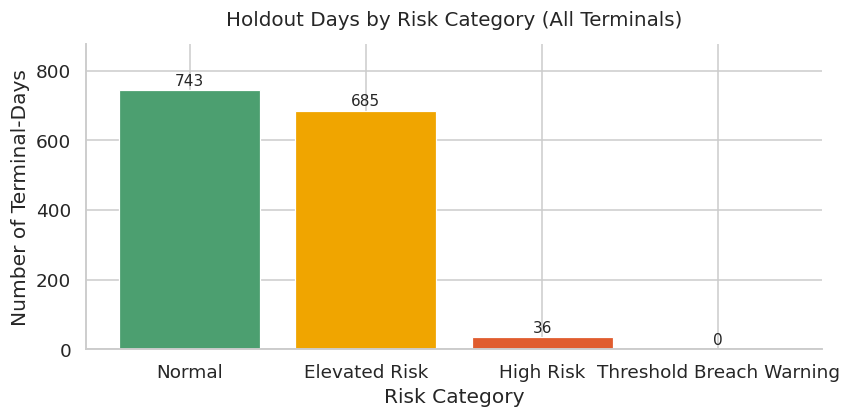


Risk category summary:


,risk_category,count
0,Normal,743
1,Elevated Risk,685
2,High Risk,36
3,Threshold Breach Warning,0


In [8]:
category_counts = (
    ds_table["risk_category"]
    .value_counts()
    .reindex(RISK_ORDER, fill_value=0)
    .reset_index()
)
category_counts.columns = ["risk_category", "count"]

palette = {
    "Normal": "#4c9f70",
    "Elevated Risk": "#f0a500",
    "High Risk": "#e05c2e",
    "Threshold Breach Warning": "#8b0000",
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    category_counts["risk_category"],
    category_counts["count"],
    color=[palette[c] for c in category_counts["risk_category"]],
    edgecolor="white",
    linewidth=0.8,
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height):,}",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("Holdout Days by Risk Category (All Terminals)", fontsize=13, pad=12)
ax.set_xlabel("Risk Category")
ax.set_ylabel("Number of Terminal-Days")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, category_counts["count"].max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

print("\nRisk category summary:")
display(category_counts)

## Warnings by terminal

The chart below breaks down High Risk and Threshold Breach Warning days by terminal. This helps operations leaders identify which terminals are most likely to experience elevated dwell conditions during the holdout period, and where proactive resource planning may be most valuable.

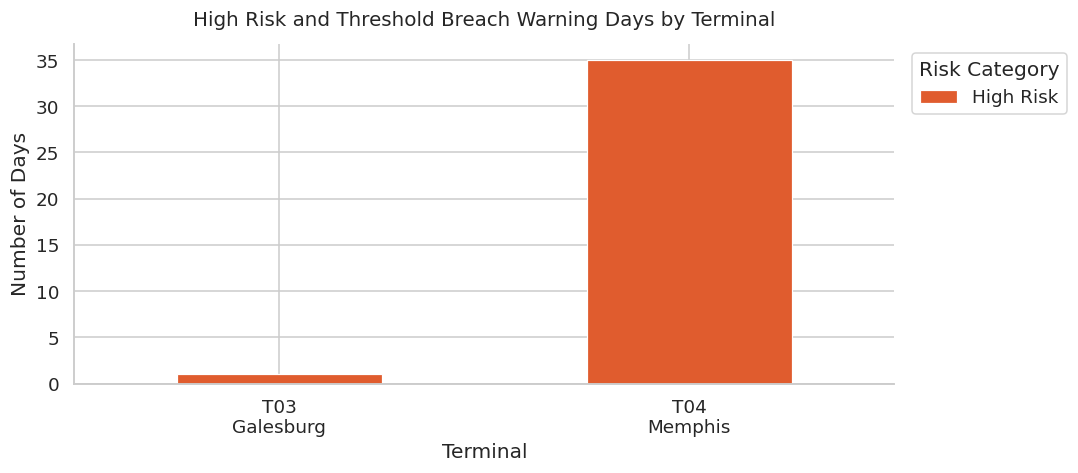


Warning counts by terminal:


,terminal_id,terminal_name,warning_days
0,T04,Memphis,35
1,T03,Galesburg,1


In [11]:
warnings_mask = ds_table["risk_category"].isin(["High Risk", "Threshold Breach Warning"])

warnings_by_terminal = (
    ds_table.loc[warnings_mask]
    .groupby(["terminal_id", "terminal_name", "risk_category"], observed=True)
    .size()
    .reset_index(name="count")
)

warnings_by_terminal["label"] = (
    warnings_by_terminal["terminal_id"].astype(str) + "\n" + warnings_by_terminal["terminal_name"]
)

pivot = (
    warnings_by_terminal
    .pivot_table(index="label", columns="risk_category", values="count", fill_value=0)
    .reindex(columns=[c for c in RISK_ORDER if c in warnings_by_terminal["risk_category"].unique()])
)

fig, ax = plt.subplots(figsize=(10, 4.5))
pivot.plot(
    kind="bar",
    ax=ax,
    color=[palette[c] for c in pivot.columns],
    edgecolor="white",
    linewidth=0.8,
)

ax.set_title("High Risk and Threshold Breach Warning Days by Terminal", fontsize=13, pad=12)
ax.set_xlabel("Terminal")
ax.set_ylabel("Number of Days")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
ax.legend(title="Risk Category", bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

print("\nWarning counts by terminal:")
display(
    ds_table.loc[warnings_mask]
    .groupby(["terminal_id", "terminal_name"])
    .size()
    .reset_index(name="warning_days")
    .sort_values("warning_days", ascending=False)
    .reset_index(drop=True)
)

## Average predicted dwell by terminal

This chart shows the average predicted next-day dwell hours by terminal across the full holdout period. The 24-hour threshold is marked as a reference line, making it easy to see which terminals are operating closest to the warning boundary on average.

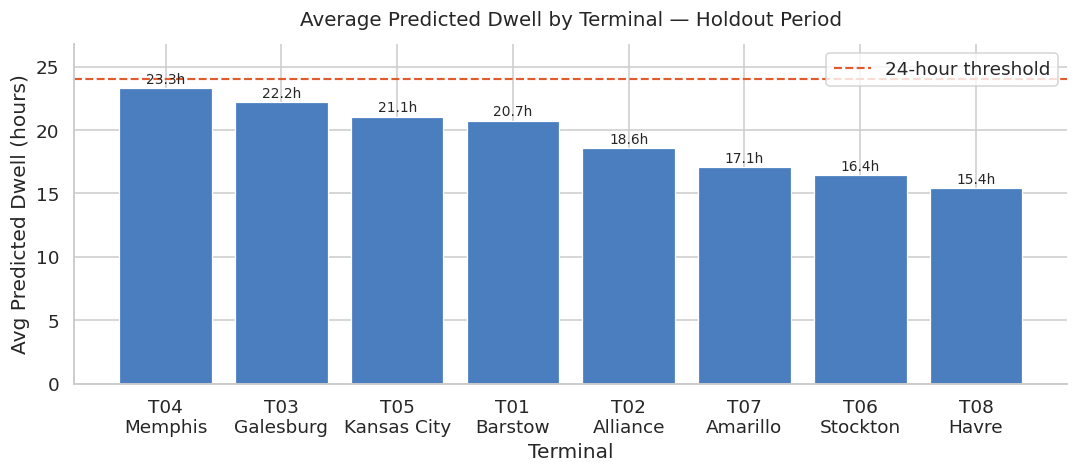


Average predicted dwell by terminal:


,terminal_id,terminal_name,predicted_dwell
0,T04,Memphis,23.305
1,T03,Galesburg,22.202
2,T05,Kansas City,21.056
3,T01,Barstow,20.745
4,T02,Alliance,18.570
5,T07,Amarillo,17.075
6,T06,Stockton,16.423
7,T08,Havre,15.400


In [13]:
avg_dwell = (
    ds_table.groupby(["terminal_id", "terminal_name"])["predicted_dwell"]
    .mean()
    .reset_index()
    .sort_values("predicted_dwell", ascending=False)
)
avg_dwell["label"] = avg_dwell["terminal_id"].astype(str) + "\n" + avg_dwell["terminal_name"]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(
    avg_dwell["label"],
    avg_dwell["predicted_dwell"],
    color="#4a7ebf",
    edgecolor="white",
    linewidth=0.8,
)

ax.axhline(24, color="#e05c2e", linestyle="--", linewidth=1.4, label="24-hour threshold")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.1f}h",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title("Average Predicted Dwell by Terminal — Holdout Period", fontsize=13, pad=12)
ax.set_xlabel("Terminal")
ax.set_ylabel("Avg Predicted Dwell (hours)")
ax.legend()
ax.set_ylim(0, avg_dwell["predicted_dwell"].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print("\nAverage predicted dwell by terminal:")
display(avg_dwell[["terminal_id", "terminal_name", "predicted_dwell"]].reset_index(drop=True))

## Resource pressure summary

The resource pressure flag highlights days where the model predicts elevated dwell and at least one operational resource — yard capacity or crew availability — is also under stress. These days represent the highest-priority intervention candidates.

In [14]:
pressure_summary = (
    ds_table.groupby("terminal_id")["resource_pressure_flag"]
    .sum()
    .reset_index()
    .rename(columns={"resource_pressure_flag": "pressure_days"})
    .merge(df[["terminal_id", "terminal_name"]].drop_duplicates(), on="terminal_id")
    .sort_values("pressure_days", ascending=False)
    .reset_index(drop=True)
)

total_pressure = ds_table["resource_pressure_flag"].sum()
total_test = len(ds_table)

print(f"Total resource pressure days: {total_pressure:,} of {total_test:,} holdout terminal-days")
print(f"({100 * total_pressure / total_test:.1f}% of holdout period)\n")
display(pressure_summary)

Total resource pressure days: 35 of 1,464 holdout terminal-days
(2.4% of holdout period)



,terminal_id,pressure_days,terminal_name
0,T04,35,Memphis
1,T01,0,Barstow
2,T02,0,Alliance
3,T03,0,Galesburg
4,T05,0,Kansas City
5,T06,0,Stockton
6,T07,0,Amarillo
7,T08,0,Havre


## Threshold validation — predicted flags vs actual outcomes

The decision-support layer flags predicted dwell at or above 24 hours as High Risk or Threshold Breach Warning. This section checks how well those flags aligned with actual holdout outcomes.

**Detection rate (recall)** measures how many real breaches were caught before they happened — high recall means fewer operational surprises. **Precision** measures how many flagged days actually breached — low precision means the model raises too many false alarms and erodes trust. Both matter operationally and should be reviewed when calibrating thresholds for production use.

In [15]:
actual_breach = y_test.values >= 24
pred_breach = ds_table["predicted_dwell"].values >= 24

n_actual = int(actual_breach.sum())
n_pred   = int(pred_breach.sum())
tp = int((actual_breach & pred_breach).sum())
fp = int((~actual_breach & pred_breach).sum())
fn = int((actual_breach & ~pred_breach).sum())

recall            = tp / n_actual if n_actual > 0 else 0
precision         = tp / n_pred   if n_pred   > 0 else 0
false_alarm_rate  = fp / n_pred   if n_pred   > 0 else 0

validation_df = pd.DataFrame({
    "Metric": [
        "Actual breaches (dwell ≥ 24h)",
        "Predicted breaches (predicted dwell ≥ 24h)",
        "True positives — correctly flagged",
        "False alarms — flagged but no actual breach",
        "Missed breaches — breached but not flagged",
        "Detection rate (recall)",
        "Precision",
        "False alarm rate (among flagged days)",
    ],
    "Value": [
        f"{n_actual:,}",
        f"{n_pred:,}",
        f"{tp:,}",
        f"{fp:,}",
        f"{fn:,}",
        f"{recall:.1%}",
        f"{precision:.1%}",
        f"{false_alarm_rate:.1%}",
    ],
})

display(validation_df)

# Rule prevalence — how common are the resource pressure thresholds in the holdout period
pct_high_yard = (df_model.loc[test_mask, "yard_occupancy_pct"] > 75).mean()
pct_low_crew  = (df_model.loc[test_mask, "crew_starts_available"] < 10).mean()

print(f"\nResource pressure threshold prevalence (holdout period):")
print(f"  Yard occupancy > 75%:       {pct_high_yard:.1%} of terminal-days")
print(f"  Crew starts available < 10: {pct_low_crew:.1%} of terminal-days")

,Metric,Value
0,Actual breaches (dwell ≥ 24h),242
1,Predicted breaches (predicted dwell ≥ 24h),36
2,True positives — correctly flagged,17
3,False alarms — flagged but no actual breach,19
4,Missed breaches — breached but not flagged,225
5,Detection rate (recall),7.0%
6,Precision,47.2%
7,False alarm rate (among flagged days),52.8%



Resource pressure threshold prevalence (holdout period):
  Yard occupancy > 75%:       24.0% of terminal-days
  Crew starts available < 10: 16.5% of terminal-days


## Model performance summary

The table below shows the complete Phase 1 and Phase 2 benchmark results. The tuned LightGBM model is the only model used to generate the decision-support outputs in this notebook. The Phase 2 LSTM experiments are included for comparison only — both failed to clear the Phase 2 performance gate and are not candidates for the decision-support layer.

In [16]:
benchmark_df = pd.DataFrame({
    "Model": [
        "Naive Persistence",
        "LightGBM Baseline",
        "LightGBM Tuned",
        "LSTM Experiment 1",
        "LSTM Experiment 2",
    ],
    "Phase": ["Phase 1", "Phase 1", "Phase 1", "Phase 2", "Phase 2"],
    "RMSE": [5.250, 3.841, 3.749, 7.576, 7.500],
    "MAE":  [4.068, 2.942, 2.879, 5.228, 5.167],
    "Used for Decision Support": ["No", "No", "Yes", "No", "No"],
})

display(benchmark_df)

,Model,Phase,RMSE,MAE,Used for Decision Support
0,Naive Persistence,Phase 1,5.250,4.068,No
1,LightGBM Baseline,Phase 1,3.841,2.942,No
2,LightGBM Tuned,Phase 1,3.749,2.879,Yes
3,LSTM Experiment 1,Phase 2,7.576,5.228,No
4,LSTM Experiment 2,Phase 2,7.500,5.167,No


## Interpretation and project framing

### What this layer does

This is a decision-support layer built directly on the tuned LightGBM next-day dwell forecasts from Phase 1. It takes the model's continuous dwell predictions and maps them to four operational risk categories plus a resource pressure flag — signals that a yard manager or dispatcher can read at a glance and act on without interpreting a raw number.

### What this layer does not do

This notebook does not predict operating ratio (OR), and it does not translate a risk classification into a specific financial outcome. Terminal dwell is one operational driver upstream of OR. A "High Risk" flag means the model forecasts elevated dwell pressure for that terminal on that day — it does not guarantee a particular cost impact or OR movement. The decision-support signals are intended to prompt operational review, not to replace human judgment.

### Business rules are transparent and adjustable

The risk thresholds (20h, 24h, 28h) and the resource pressure criteria (yard occupancy > 75%, crew starts < 10) are explicit and auditable. A terminal manager can look at any flagged day and understand exactly what triggered the classification. Operations leaders can review and update these thresholds at any time without retraining the underlying model — the forecasting layer and the rules layer are intentionally kept separate.

### Who this supports

- **Dispatch and terminal operations:** prioritize crew and equipment on days where the model flags elevated dwell risk
- **Resource planning teams:** identify days where high predicted dwell coincides with tight crew or yard capacity
- **Operating leadership:** track which terminals see the most risk days and use that pattern to inform planning decisions

### Calibration note

The thresholds used here are operationally informed starting points, not production-validated rules. In a production setting, they should be reviewed against historical outcomes — for example, measuring how often High Risk days actually resulted in service delays — and adjusted with input from terminal and operations leadership before routine use.